<h3> Method with Weighted Mean the centeroid embedding of a document and and HDBSCAN for clustering. </h3>

<h5> Imports </h5>

In [1]:
import json
import glob
import os

import numpy as np

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
from kneed import KneeLocator

import shutil

<h5> To avoid the re-embedding from scratch, we just pick-up the embedding results from the files </h5>

In [ ]:
# Read all JSON files from embeddings folder
embeddings_dir = os.path.join("data_output", "embeddings")
files_dir = "data"
embeddings_files = glob.glob(os.path.join(embeddings_dir, "*.json"))

all_results = []

print(f"Found {len(embeddings_files)} JSON files in {embeddings_dir}")

for json_file in embeddings_files:
    try:
        with open(json_file, "r", encoding="utf-8") as f:
            doc_data = json.load(f)
            all_results.append(doc_data)
        print(f"Loaded: {os.path.basename(json_file)}")
    except Exception as e:
        print(f"Error loading {json_file}: {e}")

print(f"Total documents loaded: {len(all_results)}")

<h5> Compute an Attention-pooled mean from individual chunks (page embeddings) for each document </h5>

In [3]:
def weighted_mean_doc_vector(page_embeddings, weights=None):
    if not page_embeddings:
        return None

    V = np.vstack(page_embeddings)  # (n_pages, d)

    if weights is None:
        w = np.ones(len(V), dtype="float32")
    else:
        w = np.asarray(weights, dtype="float32")
        w = w / (w.sum() + 1e-12)

    v = (w[:, None] * V).sum(axis=0)
    v /= (np.linalg.norm(v) + 1e-12)
    return v

In [4]:
for doc_result in all_results:
    page_embeddings = doc_result.get("embeddings", [])
    page_texts = [p.get("text","") for p in doc_result.get("pages", [])]
    v_doc = weighted_mean_doc_vector(page_embeddings)
    doc_result["doc_vector"] = None if v_doc is None else v_doc.tolist()

<h5> UMAP (Uniform Manifold Approximation and Projection) is a non-linear dimensionality reduction method designed to preserve neighborhood structure when projecting high-dimensional data into 2D or 3D. </h5>

In [ ]:
import umap

X_array = np.array([doc_result["doc_vector"] for doc_result in all_results if doc_result["doc_vector"] is not None])
reducer = umap.UMAP(
    n_neighbors=15,
    min_dist=0.1,
    n_components=2,
    metric="cosine",
    random_state=42
)

X_2d = reducer.fit_transform(X_array)


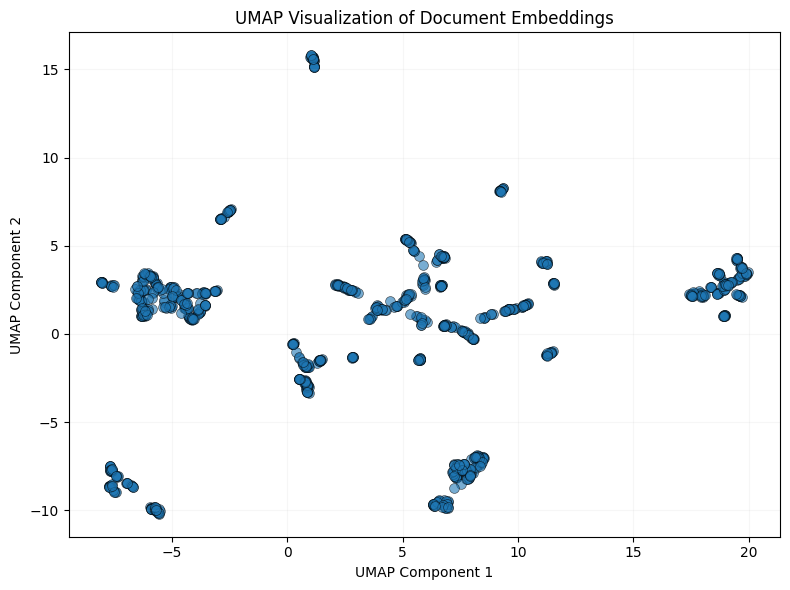

Visualized 1064 documents in 2D space
UMAP reduced dimensions from 3072 to 2


In [7]:
plt.figure(figsize=(8, 6))
plt.scatter(X_2d[:, 0], X_2d[:, 1], alpha=0.6, s=50, edgecolors='black', linewidth=0.5)
plt.title("UMAP Visualization of Document Embeddings")
plt.xlabel("UMAP Component 1")
plt.ylabel("UMAP Component 2")
plt.grid(True, alpha=0.1)
plt.tight_layout()
plt.show()

print(f"Visualized {len(X_2d)} documents in 2D space")
print(f"UMAP reduced dimensions from {X_array.shape[1]} to {X_2d.shape[1]}")

In [8]:
# Extract doc vectors from all_results
doc_vectors = []
doc_names = []

for doc in all_results:
    if doc.get('doc_vector') is not None:
        doc_vectors.append(doc['doc_vector'])
        # Extract just the filename without path
        filename = os.path.basename(doc['file'])
        doc_names.append(filename)

# Convert to numpy array
doc_vectors_array = np.array(doc_vectors)

In [ ]:
import numpy as np
import hdbscan

# doc_vectors_array = (n_docs, d) normalized document embeddings

clusterer = hdbscan.HDBSCAN(
    min_cluster_size=3,      # tune later
    min_samples=10,
    metric='euclidean'       # cosine also works but euclidean with normalized vectors = same
)

labels = clusterer.fit_predict(doc_vectors_array)

# Attach labels to documents
for doc, label in zip(all_results, labels):
    doc['cluster'] = int(label)

# Show cluster summary
unique, counts = np.unique(labels, return_counts=True)
for u, c in zip(unique, counts):
    print(f"Cluster {u}: {c} documents")

n_clusters = len(set(labels)) - (1 if -1 in labels else 0)

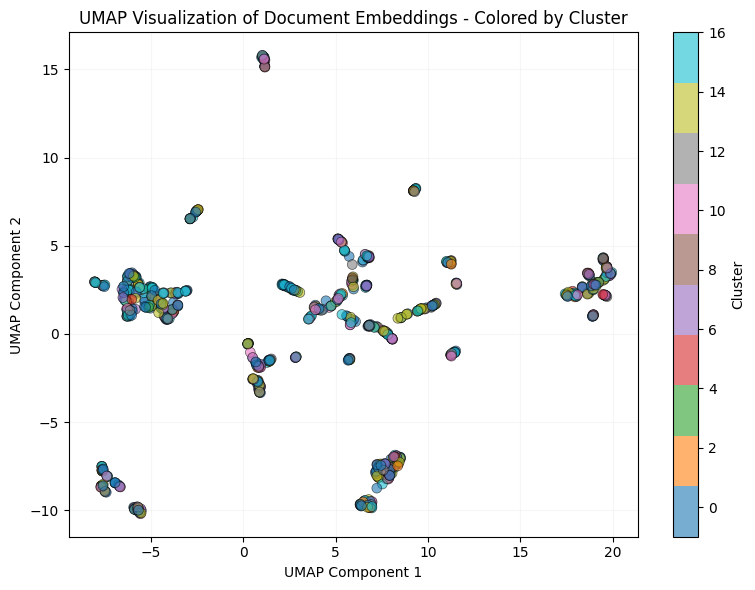

Visualized 1064 documents in 2D space
UMAP reduced dimensions from 3072 to 2


In [10]:
# Visualize UMAP with cluster colors
plt.figure(figsize=(8, 6))

# Get cluster labels for documents with vectors
cluster_labels_for_plot = []
for doc in all_results:
    if doc.get('doc_vector') is not None:
        cluster_labels_for_plot.append(doc.get('cluster', -1))

# Create scatter plot with different colors for each cluster
scatter = plt.scatter(X_2d[:, 0], X_2d[:, 1], 
                     c=cluster_labels_for_plot, 
                     cmap='tab10', 
                     s=50, 
                     alpha=0.6, 
                     edgecolors='black', 
                     linewidth=0.5)

plt.title("UMAP Visualization of Document Embeddings - Colored by Cluster")
plt.xlabel("UMAP Component 1")
plt.ylabel("UMAP Component 2")
plt.colorbar(scatter, label='Cluster')
plt.grid(True, alpha=0.1)
plt.tight_layout()
plt.show()

print(f"Visualized {len(X_2d)} documents in 2D space")
print(f"UMAP reduced dimensions from {X_array.shape[1]} to {X_2d.shape[1]}")

In [ ]:
# Create main clusters folder
clusters_main_dir = os.path.join("data_output", "clusters-11")
os.makedirs(clusters_main_dir, exist_ok=True)

# Create subfolders for each cluster and copy files
for cluster_id in range(n_clusters):
    # Create cluster subfolder
    cluster_dir = os.path.join(clusters_main_dir, f"cluster{cluster_id}")
    os.makedirs(cluster_dir, exist_ok=True)
    
    # Get documents in this cluster
    cluster_doc_count = 0
    for doc in all_results:
        if doc.get('cluster') == cluster_id:
            # Get original filename for destination
            original_filename = os.path.basename(doc['file'])
            
            # Source file path (use the full path from doc['file'])
            source_file = doc['file']
            
            # Destination file path
            dest_file = os.path.join(cluster_dir, original_filename)
            
            # Copy file to cluster folder
            if os.path.exists(source_file):
                shutil.copy2(source_file, dest_file)
                cluster_doc_count += 1
            else:
                print(f"Warning: File not found: {source_file}")
    
    print(f"Cluster {cluster_id}: {cluster_doc_count} files copied to {cluster_dir}")

print(f"All files organized into {clusters_main_dir}")